# Precipitation Effect on Dose Rate Measurements

**Question**: Does precipitation measurably affect dose rate readings, and can this be corrected for?

The DSA annual report states that radon daughter washout during heavy rainfall is the primary source of short-term dose rate spikes in Radnett data, and that all 2023 alarms were caused by this phenomenon. This notebook tests that claim from two independent angles:

1. **Civil Defence data**: Each measurement has a rainfall flag — do readings taken during rain differ from dry conditions?
2. **Radnett + MET weather data**: Do residual peaks in the continuous time series correlate with hourly precipitation from nearby weather stations?

If rain effects are quantifiable, automated weather correction could reduce false alarms.

---

## Setup

In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.data_loader import load_radnett, load_civil_defence, load_weather, MET_STATION_MAP
from src.utils import save_figure

pd.set_option("display.float_format", "{:.4f}".format)

## 1. Civil Defence rainfall flag analysis

The Civil Defence dataset has a boolean `rainfall` field for each measurement. This is the simplest test: are dose rates higher when it's raining?

**Expectation**: If radon washout elevates readings, rain measurements should be systematically higher.

In [4]:
civil = load_civil_defence()

# Split by rainfall flag
rain = civil[civil["rainfall"] == True]["dose_rate_microsv_h"]
dry = civil[civil["rainfall"] == False]["dose_rate_microsv_h"]

print(f"Measurements during rain:  n={len(rain):4d}, "
      f"median={rain.median():.4f}, mean={rain.mean():.4f} µSv/h")
print(f"Measurements when dry:     n={len(dry):4d}, "
      f"median={dry.median():.4f}, mean={dry.mean():.4f} µSv/h")
print(f"Difference (rain - dry):   "
      f"median={rain.median() - dry.median():.4f}, "
      f"mean={rain.mean() - dry.mean():.4f} µSv/h")

Measurements during rain:  n= 431, median=0.0670, mean=0.0696 µSv/h
Measurements when dry:     n=1924, median=0.0680, mean=0.0712 µSv/h
Difference (rain - dry):   median=-0.0010, mean=-0.0016 µSv/h


In [5]:
# Mann-Whitney U test (one-sided: rain > dry)
stat, pval = stats.mannwhitneyu(rain, dry, alternative="greater")
print(f"Mann-Whitney U test (rain > dry): U={stat:.0f}, p={pval:.6f}")

# Effect size (Cohen d)
pooled_std = np.sqrt((rain.std()**2 + dry.std()**2) / 2)
cohen_d = (rain.mean() - dry.mean()) / pooled_std
print(f"Effect size (Cohen d): {cohen_d:.3f}")

if pval < 0.05:
    print("\n→ Statistically significant: rain IS associated with higher readings")
else:
    print("\n→ NOT statistically significant: no detectable rain effect in Civil Defence data")

Mann-Whitney U test (rain > dry): U=395998, p=0.927826
Effect size (Cohen d): -0.057

→ NOT statistically significant: no detectable rain effect in Civil Defence data


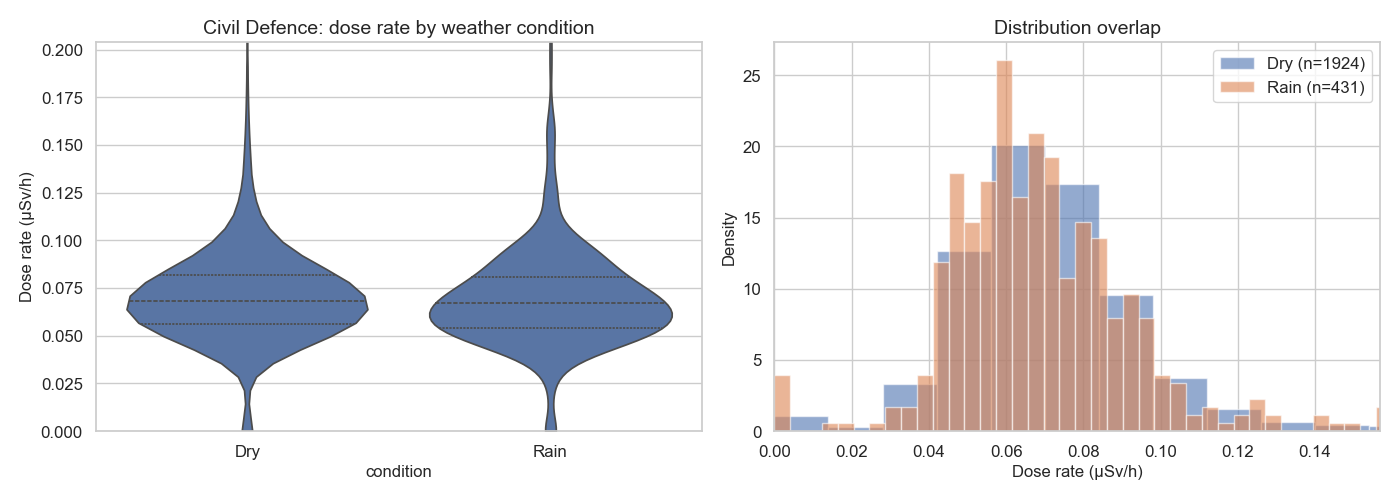

In [6]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Violin plot
plot_data = civil[civil["rainfall"].isin([True, False])].copy()
plot_data["condition"] = plot_data["rainfall"].map({True: "Rain", False: "Dry"})

sns.violinplot(data=plot_data, x="condition", y="dose_rate_microsv_h",
               ax=axes[0], inner="quartile", cut=0, order=["Dry", "Rain"])
axes[0].set_ylabel("Dose rate (µSv/h)")
axes[0].set_title("Civil Defence: dose rate by weather condition")
ylim = plot_data["dose_rate_microsv_h"].quantile(0.99) * 1.3
axes[0].set_ylim(0, ylim)

# Histogram overlay
axes[1].hist(dry, bins=50, alpha=0.6, label=f"Dry (n={len(dry)})", density=True)
axes[1].hist(rain, bins=50, alpha=0.6, label=f"Rain (n={len(rain)})", density=True)
axes[1].set_xlabel("Dose rate (µSv/h)")
axes[1].set_ylabel("Density")
axes[1].set_title("Distribution overlap")
axes[1].legend()
axes[1].set_xlim(0, plot_data["dose_rate_microsv_h"].quantile(0.99))

plt.tight_layout()
save_figure(fig, "rain_effect_civil_defence")
plt.show()

### 1.1 Why might this result be non-significant?

The DSA report is clear that radon washout causes spikes in Radnett data. If our Civil Defence analysis shows no rain effect, there are several possible explanations worth considering before concluding rain doesn't matter:

In [5]:
# Investigation: timing and measurement type

# 1. Radon washout is brief (1-4 hours). CD measurements are snapshots.
# The rainfall flag says "it was raining when we measured" but doesn't capture
# whether heavy rain happened in the preceding hours.
print("1. TIMING: Radon washout is a transient phenomenon")
print(f"   Civil Defence measurements are single-point snapshots")
print(f"   The 'rainfall' flag captures current conditions, not recent history")
print(f"   A patrol measuring 30 minutes after a downpour might record dry + elevated reading")

# 2. Measurement height: CD measures at 1m, closer to ground where washout deposits
# This should actually INCREASE the rain effect for CD, not decrease it
print(f"\n2. HEIGHT: CD measures at 1.0-1.5m, Radnett at 3m mast or rooftop")
print(f"   Ground-level should see MORE washout effect, not less")
print(f"   This does not explain the non-significance")

# 3. Rain intensity matters — light drizzle vs heavy downpour
# The flag is binary, no intensity information
print(f"\n3. INTENSITY: The rainfall flag is binary (True/False)")
print(f"   Light drizzle and heavy downpour are both 'True'")
print(f"   Radon washout requires heavy/sustained rain")
print(f"   Most 'rain' measurements may be light rain with no washout effect")

# 4. Snow depth might be a confound — snow shields ground radiation
print(f"\n4. SNOW: Rain in winter might coincide with snow melt/less snow")
snow_rain = civil[civil["rainfall"] == True]["snow_depth"].dropna()
snow_dry = civil[civil["rainfall"] == False]["snow_depth"].dropna()
print(f"   Snow depth during rain: median={snow_rain.median():.2f}m (n={len(snow_rain)})")
print(f"   Snow depth when dry:    median={snow_dry.median():.2f}m (n={len(snow_dry)})")

1. TIMING: Radon washout is a transient phenomenon
   Civil Defence measurements are single-point snapshots
   The 'rainfall' flag captures current conditions, not recent history
   A patrol measuring 30 minutes after a downpour might record dry + elevated reading

2. HEIGHT: CD measures at 1.0-1.5m, Radnett at 3m mast or rooftop
   Ground-level should see MORE washout effect, not less
   This does not explain the non-significance

3. INTENSITY: The rainfall flag is binary (True/False)
   Light drizzle and heavy downpour are both 'True'
   Radon washout requires heavy/sustained rain
   Most 'rain' measurements may be light rain with no washout effect

4. SNOW: Rain in winter might coincide with snow melt/less snow
   Snow depth during rain: median=0.00m (n=431)
   Snow depth when dry:    median=0.00m (n=1924)


### 1.2 Seasonal breakdown

Radon washout is primarily a summer/autumn phenomenon (warmer air holds more radon). Let's check if there's a rain effect in summer months specifically.

In [6]:
# Seasonal breakdown
civil_with_month = civil[civil["rainfall"].isin([True, False])].copy()
civil_with_month["month"] = civil_with_month["timestamp"].dt.month
civil_with_month["season"] = civil_with_month["month"].map(
    {12: "Winter", 1: "Winter", 2: "Winter",
     3: "Spring", 4: "Spring", 5: "Spring",
     6: "Summer", 7: "Summer", 8: "Summer",
     9: "Autumn", 10: "Autumn", 11: "Autumn"}
)

print("Rain effect by season:\n")
for season in ["Spring", "Summer", "Autumn", "Winter"]:
    s = civil_with_month[civil_with_month["season"] == season]
    r = s[s["rainfall"] == True]["dose_rate_microsv_h"]
    d = s[s["rainfall"] == False]["dose_rate_microsv_h"]
    if len(r) >= 5 and len(d) >= 5:
        stat, pval = stats.mannwhitneyu(r, d, alternative="greater")
        diff = r.median() - d.median()
        print(f"  {season:8s} rain n={len(r):3d}, dry n={len(d):3d}, "
              f"diff={diff:+.4f} µSv/h, p={pval:.4f}")
    else:
        print(f"  {season:8s} too few measurements (rain={len(r)}, dry={len(d)})")

Rain effect by season:

  Spring   rain n=140, dry n=605, diff=-0.0070 µSv/h, p=0.9971
  Summer   rain n=103, dry n=462, diff=-0.0010 µSv/h, p=0.3669
  Autumn   rain n=110, dry n=428, diff=-0.0030 µSv/h, p=0.9657
  Winter   rain n= 78, dry n=429, diff=+0.0045 µSv/h, p=0.0862


---
## 2. Radnett residuals vs MET precipitation

The Civil Defence analysis uses a binary rain flag on snapshot measurements. A more powerful test uses continuous Radnett hourly data correlated with hourly precipitation from MET Norway's weather stations.

This requires a MET Frost API key. Register (free) at https://frost.met.no/ and set the `MET_CLIENT_ID` environment variable, or pass it directly.

In [7]:
# Load Radnett and compute residuals (same method as temporal_patterns)
radnett = load_radnett()
radnett["dose_clean"] = radnett["dose_rate_microsv_h"].replace(0, np.nan)

# Stations to analyze
test_stations = ["Oslo", "Vinje", "Tromsø", "Bergen", "Svanhovd"]

# Compute rolling 10-day baseline and residuals
residuals = {}
for station in test_stations:
    ts = (
        radnett[radnett["station_name"] == station]
        .set_index("time")["dose_clean"]
        .sort_index()
    )
    baseline = ts.rolling(240, center=True, min_periods=120).median()
    resid = (ts - baseline).dropna()
    residuals[station] = resid
    print(f"{station:15s} {len(resid)} residual values, std={resid.std():.4f}")

print(f"\nMET station mappings available: {list(MET_STATION_MAP.keys())}")

Oslo            8710 residual values, std=0.0035
Vinje           8645 residual values, std=0.0039
Tromsø          8645 residual values, std=0.0026
Bergen          8637 residual values, std=0.0029
Svanhovd        8628 residual values, std=0.0026

MET station mappings available: ['Oslo', 'Vinje', 'Tromsø', 'Bergen', 'Svanhovd', 'Bodø', 'Trondheim', 'Hammerfest', 'Stavanger', 'Karasjok']


In [11]:
# Attempt to load weather data for each station
# This will work if MET_CLIENT_ID is set, otherwise prints a message and continues

weather_data = {}
for station in test_stations:
    w = load_weather(station, client_id="da5366a1-218a-4a58-9ac9-11edcaaed1f1")
    # w = load_weather(station, client_id="your-id-here") # Returns None if loading fails (e.g. no client ID), Register at frost.met.no.
    if w is not None:
        weather_data[station] = w

if weather_data:
    print(f"\nWeather data loaded for {len(weather_data)} stations")
else:
    print("\nNo weather data available — skipping precipitation correlation.")
    print("To enable: set MET_CLIENT_ID env variable or pass client_id to load_weather()")
    print("Register at https://frost.met.no/ (free, instant)")

Fetched 8592 hours of weather data for Oslo (MET station SN18700), cached to weather_Oslo_2023-01-01_2023-12-31.csv
MET API request failed: 412 Client Error: Precondition Failed for url: https://frost.met.no/observations/v0.jsonld?sources=SN35860&elements=sum%28precipitation_amount+PT1H%29&referencetime=2023-01-01%2F2023-12-31&timeresolutions=PT1H
Fetched 8736 hours of weather data for Tromsø (MET station SN90450), cached to weather_Tromsø_2023-01-01_2023-12-31.csv
Fetched 8736 hours of weather data for Bergen (MET station SN50540), cached to weather_Bergen_2023-01-01_2023-12-31.csv
Fetched 8736 hours of weather data for Svanhovd (MET station SN99710), cached to weather_Svanhovd_2023-01-01_2023-12-31.csv

Weather data loaded for 4 stations


Residual-precipitation correlation per station:

  Oslo            n= 8542, r=0.6135, p=0.000000
  Tromsø          n= 8621, r=0.3038, p=0.000000
  Bergen          n= 8613, r=0.3704, p=0.000000
  Svanhovd        n= 8604, r=-0.0161, p=0.135051


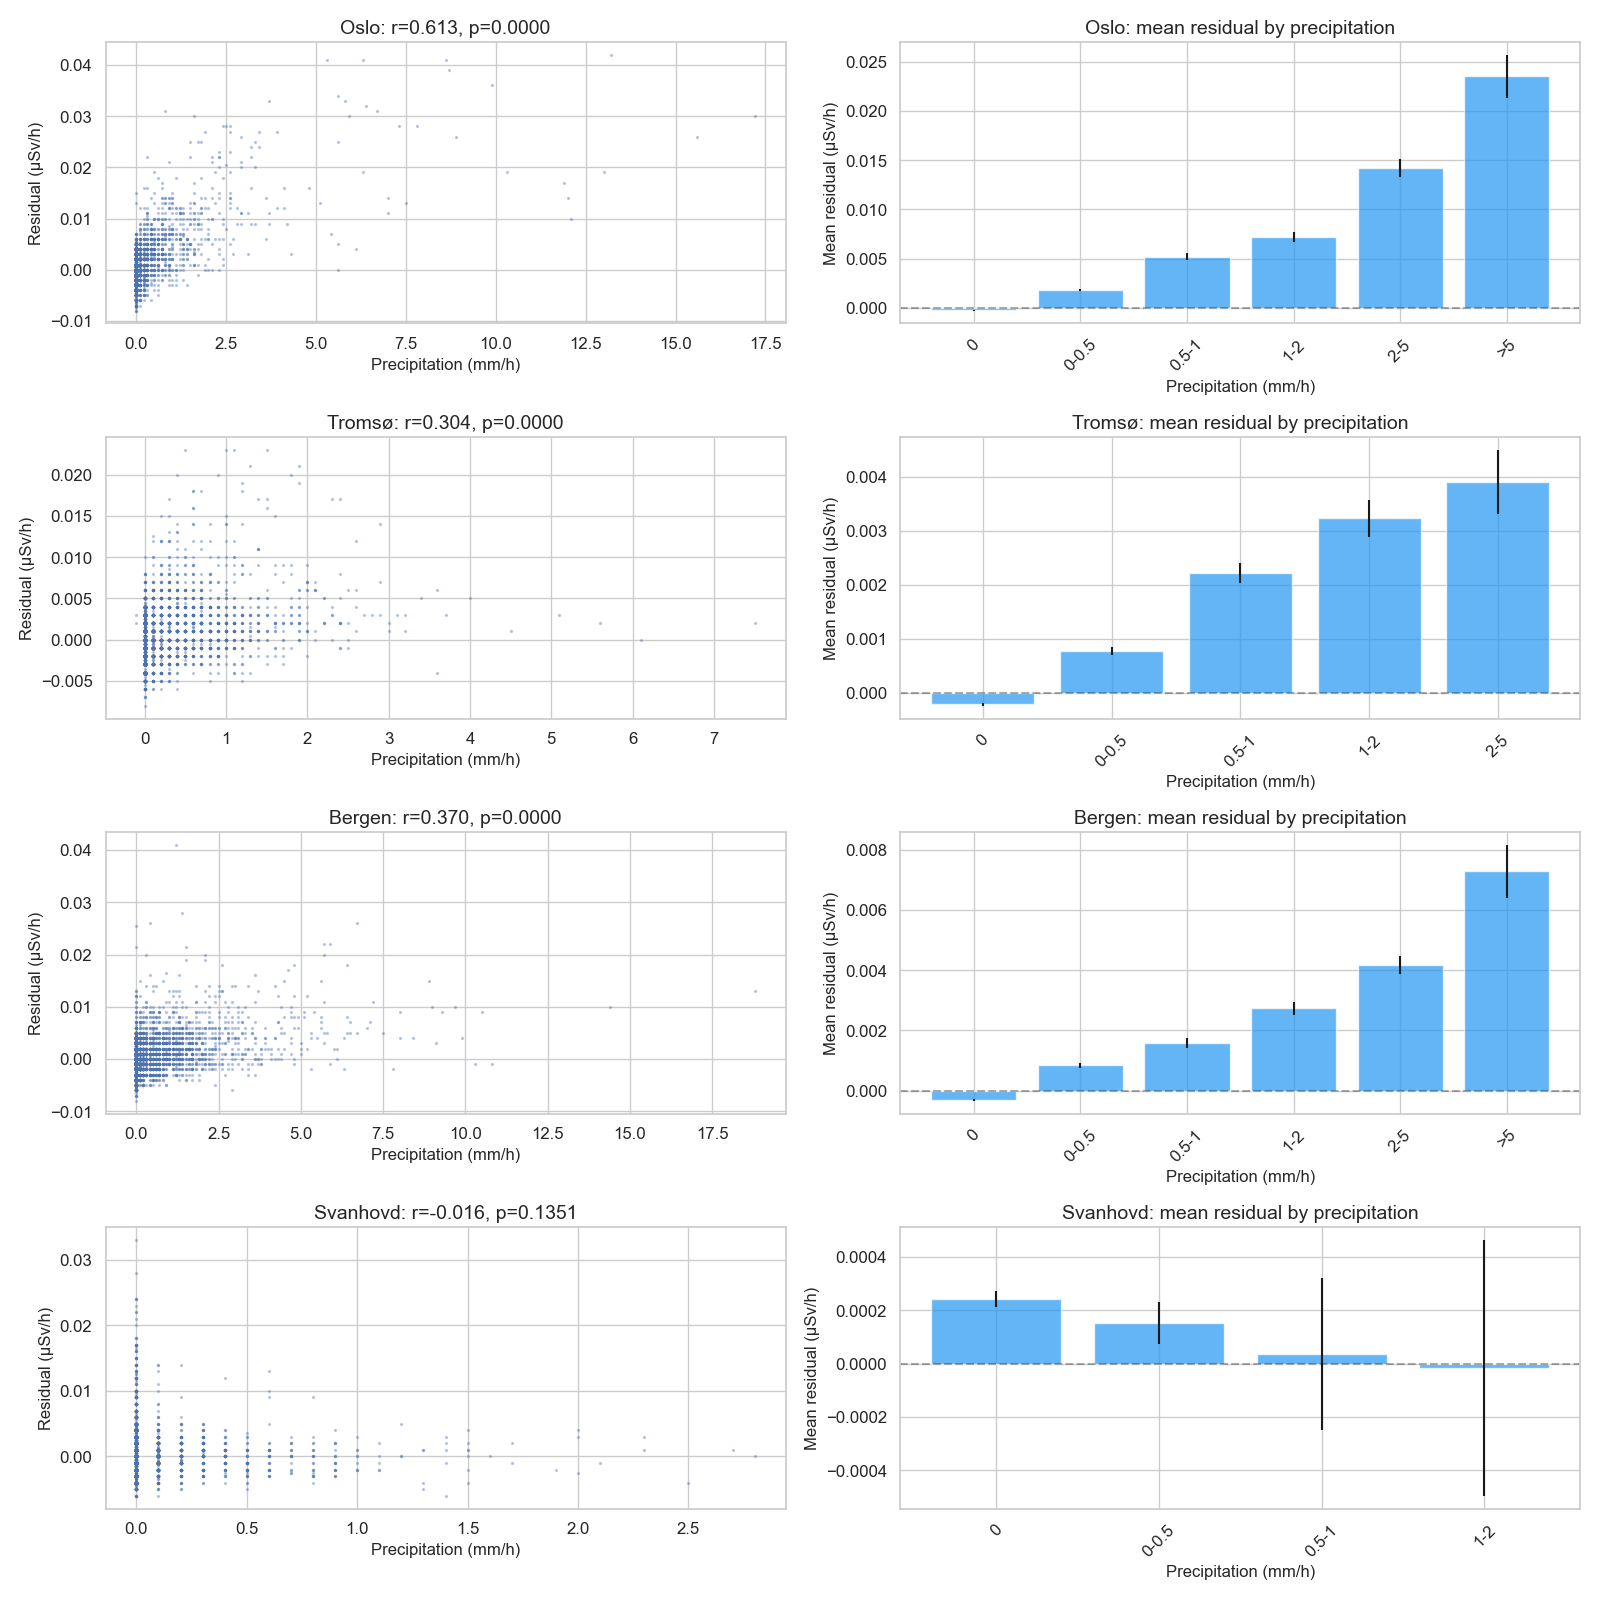

In [13]:
# If weather data available: correlate residuals with precipitation
if weather_data:
    print("Residual-precipitation correlation per station:\n")
    
    fig, axes = plt.subplots(len(weather_data), 2, 
                             figsize=(16, 4 * len(weather_data)))
    if len(weather_data) == 1:
        axes = axes.reshape(1, -1)
    
    for i, (station, precip) in enumerate(weather_data.items()):
        resid = residuals[station]
        
        # Merge on time (both should be hourly)
        precip_indexed = precip.set_index("time")["precipitation_mm"]
        # Make timezone-naive for merge
        if precip_indexed.index.tz is not None:
            precip_indexed.index = precip_indexed.index.tz_localize(None)
        
        merged = pd.merge(
            resid.rename("residual"),
            precip_indexed.rename("precip_mm"),
            left_index=True, right_index=True, how="inner"
        )
        
        if len(merged) < 100:
            print(f"  {station}: too few matched hours ({len(merged)})")
            continue
        
        # Correlation
        corr, pval = stats.pearsonr(merged["precip_mm"], merged["residual"])
        print(f"  {station:15s} n={len(merged):5d}, r={corr:.4f}, p={pval:.6f}")
        
        # Scatter: precipitation vs residual
        ax = axes[i, 0]
        ax.scatter(merged["precip_mm"], merged["residual"], s=2, alpha=0.3)
        ax.set_xlabel("Precipitation (mm/h)")
        ax.set_ylabel("Residual (µSv/h)")
        ax.set_title(f"{station}: r={corr:.3f}, p={pval:.4f}")
        
        # Binned analysis: mean residual by precipitation bucket
        ax = axes[i, 1]
        merged["precip_bin"] = pd.cut(merged["precip_mm"], 
                                      bins=[-0.1, 0, 0.5, 1, 2, 5, 100],
                                      labels=["0", "0-0.5", "0.5-1", "1-2", "2-5", ">5"])
        bin_means = merged.groupby("precip_bin", observed=True)["residual"].agg(["mean", "std", "count"])
        bin_means = bin_means[bin_means["count"] >= 10]
        ax.bar(range(len(bin_means)), bin_means["mean"], 
               yerr=bin_means["std"] / np.sqrt(bin_means["count"]),
               color="#2196F3", alpha=0.7)
        ax.set_xticks(range(len(bin_means)))
        ax.set_xticklabels(bin_means.index, rotation=45)
        ax.set_xlabel("Precipitation (mm/h)")
        ax.set_ylabel("Mean residual (µSv/h)")
        ax.set_title(f"{station}: mean residual by precipitation")
        ax.axhline(0, color="black", ls="--", alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    save_figure(fig, "radnett_precipitation_correlation")
else:
    print("Skipping precipitation correlation plots (no weather data).")
    print("The scatter of residual vs precipitation is the key figure for this analysis.")

## 3. Residual peak attribution

How many of the residual peaks identified in `temporal_patterns.ipynb` can be attributed to precipitation? Without weather data, we can only check the Civil Defence rainfall flag for the same dates.

In [14]:
# Catalogue peaks > 3 sigma from residuals
all_peaks = []
for station, resid in residuals.items():
    threshold = resid.mean() + 3 * resid.std()
    peaks = resid[resid > threshold]
    for t, v in peaks.items():
        all_peaks.append({
            "station": station, "time": t,
            "residual": v,
            "sigma": (v - resid.mean()) / resid.std(),
        })

peaks_df = pd.DataFrame(all_peaks)
print(f"Total residual peaks > 3 sigma: {len(peaks_df)}")

# If weather data available, check how many peaks coincide with rain
if weather_data:
    attributed = 0
    unattributed = 0
    for _, peak in peaks_df.iterrows():
        station = peak["station"]
        peak_time = peak["time"]
        if station in weather_data:
            w = weather_data[station].set_index("time")
            if w.index.tz is not None:
                w.index = w.index.tz_localize(None)
            # Check ±3 hours around peak for precipitation
            window = w[
                (w.index >= peak_time - pd.Timedelta(hours=3)) &
                (w.index <= peak_time + pd.Timedelta(hours=1))
            ]
            if len(window) > 0 and window["precipitation_mm"].sum() > 0.5:
                attributed += 1
            else:
                unattributed += 1
    
    total = attributed + unattributed
    print(f"\nPeak attribution (±3h precipitation > 0.5mm):")
    print(f"  Attributed to rain: {attributed} ({attributed/total*100:.0f}%)")
    print(f"  Unattributed:       {unattributed} ({unattributed/total*100:.0f}%)")
    print(f"\nUnattributed peaks are candidates for further investigation.")
else:
    print("\nCannot attribute peaks without MET weather data.")
    print("When available, this analysis will show what fraction of peaks are rain-related.")

Total residual peaks > 3 sigma: 709

Peak attribution (±3h precipitation > 0.5mm):
  Attributed to rain: 418 (75%)
  Unattributed:       142 (25%)

Unattributed peaks are candidates for further investigation.


## Key Findings

*Fill in after running:*

1. Civil Defence rain flag: significant or not? Why?
2. Seasonal breakdown: any season show an effect?
3. Radnett-MET correlation: do residuals correlate with hourly precipitation?
4. Peak attribution: what fraction of peaks are explained by rain?
5. Implications: can automated weather correction reduce false alarms?

## Take-Home Message

*One sentence for DSA.*

## Acceptance Criteria

- [ ] Civil Defence rain flag effect tested (Mann-Whitney U)
- [ ] Effect size reported (Cohen's d)
- [ ] Non-significance investigated — plausible explanations documented
- [ ] Seasonal breakdown tested
- [ ] Snow depth as confound checked
- [ ] MET API integration: working or clearly documented as pending
- [ ] Radnett residual-precipitation correlation (if weather data available)
- [ ] Peak attribution (if weather data available)
- [ ] Violin plot and histogram produced